In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(
    "../processed_data/eda_cleaned.csv"
)

In [3]:
df.head().T

,0,1,2,3,4
year,2025,2025,2025,2025,2025
month,1,1,1,1,1
carrier,G4,G4,G4,G4,G4
carrier_name,Allegiant Air,Allegiant Air,Allegiant Air,Allegiant Air,Allegiant Air
airport,ELM,ELP,EUG,EVV,EWR
airport_name,"Elmira/Corning, NY: Elmira/Corning Regional","El Paso, TX: El Paso International","Eugene, OR: Mahlon Sweet Field","Evansville, IN: Evansville Regional","Newark, NJ: Newark Liberty International"
arr_flights,30,2,28,18,31
arr_del15,0,0,8,1,5
carrier_ct,0.0,0.0,3.74,0.0,2.17
weather_ct,0.0,0.0,0.0,1.0,0.0


In [4]:
df = df.drop(columns= ['carrier','airport'])

In [5]:
df.shape

(397283, 20)

In [6]:
from ydata_profiling import ProfileReport

In [7]:
profile = ProfileReport(
    df,
    title="Optimized Dataset Report",
    # Disables expensive scatter plots for the 17 numerical variables
    interactions=None, 
    # Prevents slow text-metric checks on your 2 categorical columns
    vars={"cat": {"length": False, "words": False, "characters": False}},
    # Keeps correlations active but limits their calculation depth
    correlations={
        "auto": {"calculate": True},
        "pearson": {"calculate": True},
        "spearman": {"calculate": False},  # Too slow for 398k rows
    }
)

profile.to_file("optimized_report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 20/20 [00:01<00:00, 14.40it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

NOW WE DEFINE OUR TARGET VARIABLE y AND THE FEATURES USE TO PREDICT IT

In [6]:
y = df['arr_delay']

EXPERIMENTING

In [7]:
df_model = df.drop(columns=['carrier_delay', 'weather_delay', 'nas_delay',
        'security_delay', 'late_aircraft_delay','arr_delay','delay_rate','carrier_ct', 'weather_ct', 'nas_ct', 'security_ct',
       'late_aircraft_ct','arr_del15', 'arr_cancelled', 'arr_diverted'])

In [8]:
df_model.columns

Index(['year', 'month', 'carrier_name', 'airport_name', 'arr_flights'], dtype='object')

In [9]:
x = df_model

In [10]:
x.shape

(397283, 5)

In [11]:
df_model.shape

(397283, 5)

In [12]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397283 entries, 0 to 397282
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   year          397283 non-null  int64 
 1   month         397283 non-null  int64 
 2   carrier_name  397283 non-null  object
 3   airport_name  397283 non-null  object
 4   arr_flights   397283 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 15.2+ MB


In [13]:
df_model.describe().T

,count,mean,std,min,25%,50%,75%,max
year,397283.0,2014.417476,6.475406,2003.0,2009.0,2015.0,2020.0,2025.0
month,397283.0,6.524981,3.463720,1.0,4.0,7.0,10.0,12.0
arr_flights,397283.0,361.924646,994.267241,1.0,56.0,113.0,255.0,21977.0


In [14]:
df_model["airport_name"].nunique()

447

In [15]:
df_model["carrier_name"].nunique()

51

In [16]:
#df_model['cancel_rate'] = (df_model['arr_cancelled']/df['arr_flights'])

In [17]:
#cancel_rate = df_model.groupby('carrier_name')['cancel_rate'].mean()
#print(cancel_rate.head())

In [18]:
#df_model['divert_rate'] = df_model['arr_diverted']/df_model['arr_flights']

In [19]:
"""divert_rate = df_model.groupby('carrier_name')['divert_rate'].mean()
print(divert_rate.head())"""

"divert_rate = df_model.groupby('carrier_name')['divert_rate'].mean()\nprint(divert_rate.head())"

FROM THE EDA FILE WE CAN SEE THE PLOT FOR AVG MONTHLY DELAY FROM WHERE ITS CLEAR THAT THE DELAYS ARE MAXIMUN IN THE JUNE, JULY AND DECEMBER

In [17]:
df_model['peak_delay'] = df_model['month'].isin([6,7,12]).astype(int)

In [18]:
df_model.sample(13).T

,374404,365326,98395,346155,86613,19210,70204,320153,270571,311614,14695,138463,328260
year,2004,2005,2020,2006,2021,2024,2021,2007,2010,2008,2024,2019,2007
month,11,5,9,6,4,3,12,11,8,4,6,1,6
carrier_name,AirTran Airways Corporation,Continental Air Lines Inc.,Allegiant Air,Delta Air Lines Inc.,United Air Lines Network,Spirit Airlines,American Airlines Network,US Airways Inc.,ExpressJet Airlines Inc.,American Eagle Airlines Inc.,JetBlue Airways,Mesa Airlines Inc.,United Air Lines Inc.
airport_name,"Pensacola, FL: Pensacola International","Chicago, IL: Chicago Midway International","Sanford, FL: Orlando Sanford International","San Francisco, CA: San Francisco International","Nashville, TN: Nashville International","Baltimore, MD: Baltimore/Washington Internatio...","Santa Barbara, CA: Santa Barbara Municipal","Baltimore, MD: Baltimore/Washington Internatio...","Dallas/Fort Worth, TX: Dallas/Fort Worth Inter...","Mobile, AL: Mobile Regional","Syracuse, NY: Syracuse Hancock International","Columbus, OH: John Glenn Columbus International","Wichita, KS: Wichita Dwight D Eisenhower National"
arr_flights,60,99,364,518,107,466,61,375,238,137,90,122,142
peak_delay,0,0,0,1,0,0,1,0,0,0,1,0,1


In [19]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397283 entries, 0 to 397282
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   year          397283 non-null  int64 
 1   month         397283 non-null  int64 
 2   carrier_name  397283 non-null  object
 3   airport_name  397283 non-null  object
 4   arr_flights   397283 non-null  int64 
 5   peak_delay    397283 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 18.2+ MB


In [20]:
df_model.nunique()

year              23
month             12
carrier_name      51
airport_name     447
arr_flights     7641
peak_delay         2
dtype: int64

NOW I WILL ENCODE THE CATEGORICAL VARIABLES

In [21]:
df_model['carrier_name'].value_counts()

carrier_name
SkyWest Airlines Inc.                        46103
ExpressJet Airlines Inc.                     24626
Delta Air Lines Inc.                         20555
Mesa Airlines Inc.                           17109
American Eagle Airlines Inc.                 15404
American Airlines Inc.                       14432
Envoy Air                                    14243
United Air Lines Inc.                        13964
JetBlue Airways                              13639
Southwest Airlines Co.                       12668
Atlantic Southeast Airlines                  12158
Delta Air Lines Network                      11488
US Airways Inc.                              10692
Allegiant Air                                10256
Endeavor Air Inc.                             9302
American Airlines Network                     9248
Alaska Airlines Inc.                          9130
United Air Lines Network                      8755
Southwest Airlines                            8317
Northwest Airlines

In [22]:
counts = df_model['airport_name'].value_counts()

dummy = df_model[df_model['airport_name'].isin(counts[counts == 1].index)]

In [23]:
print(dummy.value_counts())

year  month  carrier_name                 airport_name                                           arr_flights  peak_delay
2004  4      Atlantic Southeast Airlines  Columbus, MS: Columbus AFB                             1            0             1
      7      SkyWest Airlines Inc.        Spokane, WA: Fairchild AFB                             1            1             1
2006  9      SkyWest Airlines Inc.        Rapid City, SD: Ellsworth AFB                          1            0             1
2007  4      Pinnacle Airlines Inc.       Greenville, MS: Greenville Mid Delta                   2            0             1
      5      SkyWest Airlines Inc.        Kansas City, MO: Charles B. Wheeler Downtown           1            0             1
2017  11     SkyWest Airlines Inc.        Fort Collins/Loveland, CO: Northern Colorado Regional  1            0             1
2018  1      Allegiant Air                Youngstown/Warren, OH: Youngstown-Warren Regional      2            0            

In [27]:
df_model['airport_name'].value_counts()

airport_name
Detroit, MI: Detroit Metro Wayne County              3687
Pittsburgh, PA: Pittsburgh International             3638
Indianapolis, IN: Indianapolis International         3633
Kansas City, MO: Kansas City International           3604
Raleigh/Durham, NC: Raleigh-Durham International     3497
                                                     ... 
Youngstown/Warren, OH: Youngstown-Warren Regional       1
Greenville, MS: Greenville Mid Delta                    1
Rapid City, SD: Ellsworth AFB                           1
Spokane, WA: Fairchild AFB                              1
Columbus, MS: Columbus AFB                              1
Name: count, Length: 447, dtype: int64

In [24]:
x.columns

Index(['year', 'month', 'carrier_name', 'airport_name', 'arr_flights',
       'peak_delay'],
      dtype='object')

In [25]:
x.shape

(397283, 6)

In [26]:
from sklearn.model_selection import train_test_split

In [27]:
x_train, x_test, y_train, y_test = train_test_split(
    x,y, test_size=0.3, random_state=42
)

In [28]:
print(x_train.shape)
print(x_test.shape)

(278098, 6)
(119185, 6)


In [29]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [30]:
ohe = OneHotEncoder(
    drop= "first",
    handle_unknown="ignore"
)

In [31]:
transformer = ColumnTransformer(
    transformers=[
        (
            'cat',
            ohe,
            ['carrier_name', 'airport_name']
        )
    ],
    remainder= 'passthrough'
)

In [32]:
x_train_encoded = transformer.fit_transform(x_train)
x_test_encoded = transformer.transform(x_test)

c:\Users\sarth\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


THE WARNING IS GIVEN BECAUSE THERE ARE FEW AIRPORTS WHICH GOT SPLIT UP IN SUCH A WAY THAT THEY ARE ONLY PRESENT IN 
ONE OF THE SET i.e EITHER IN TRAIN OR IN TEST

In [33]:
print(x_train_encoded.shape)
print(x_test_encoded.shape)

(278098, 497)
(119185, 497)


FIRST I WANT TO CHECK WHETHER LINEAR REGRESSION REALLY HELPS IN PREDICTING y BY CHECKING WHETHER THE ASSUMPTIONS THAT THE RESIDUALS FOLLOWS A NORMAL DISTRIBUTION AND HOMOSCEDASTICITY IS MET OR NOT

In [34]:
from sklearn.linear_model import LinearRegression

In [35]:
lr = LinearRegression()
lr.fit(x_train_encoded, y_train)

y_pred = lr.predict(x_test_encoded)
y_train_pred = lr.predict(x_train_encoded)

In [36]:
y_pred

array([  -31.24705789, -1288.89292047,   479.63764077, ...,
        3501.36639011, 12417.04041514,  4005.42922811], shape=(119185,))

In [37]:
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

mae_test = mean_absolute_error(y_test, y_pred)
mae_train = mean_absolute_error(y_train, y_train_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred))
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))

r2_test = r2_score(y_test,y_pred)
r2_train = r2_score(y_train, y_train_pred)

In [38]:
print("MAE for test: ",mae_test)
print("MAE for train: ",mae_train)
print("RMSE for test: ",rmse_test)
print("RMSE for train: ",rmse_train)
print("r2 for test: ",r2_test)
print("r2 for train: ",r2_train)

MAE for test:  2016.3394616920023
MAE for train:  2004.7894566739099
RMSE for test:  5822.165217766521
RMSE for train:  5921.790947446959
r2 for test:  0.7899131943525612
r2 for train:  0.785456661672381


In [39]:
residuals = y_test - y_pred

In [40]:
residuals

395207     200.247058
375356    1305.892920
312374    1286.362359
351344     913.157696
34536    -1717.675486
             ...     
120896   -2541.793113
377894     592.684479
315947   -1408.366390
377678   -2501.040415
358940     426.570772
Name: arr_delay, Length: 119185, dtype: float64

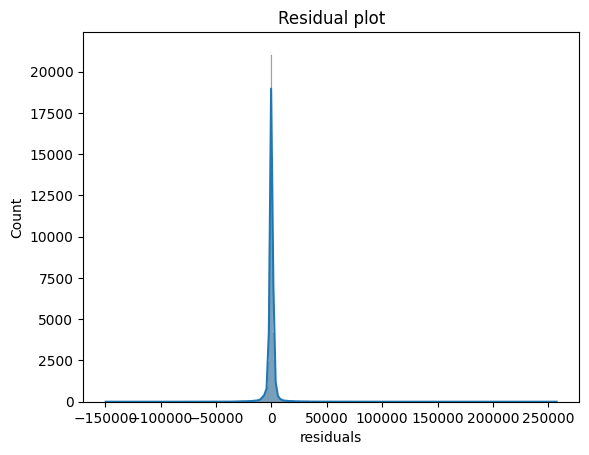

In [41]:
sns.histplot(residuals, kde=True)
plt.title("Residual plot")
plt.xlabel("residuals")
plt.show()

### HERE A SHARP POINTED KIND OF SHAPE IS SEEN INSTEAD OF THE NOEMAL BELL CURVE HENCE RESIDUALS DONOT SEEM TO FOLLOW NORMAL DISTRIBUTION

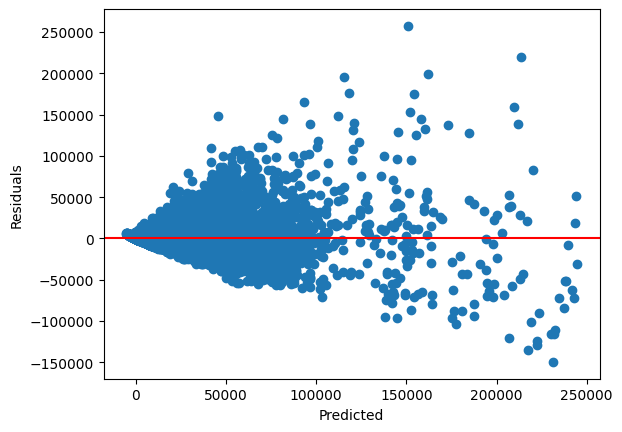

In [42]:
plt.scatter(y_pred, residuals)
plt.axhline(0, color='red')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.show()

I attempted to predict **`arr_delay` (total arrival delay minutes)** for a given airport–carrier combination using features such as `year`, `month`, arr_flights, carrier and airport name and peak delay

1. Multicollinearity

The above variables were choosed because several variables exhibit strong linear relationships with one another.

In particular:

`arr_del15 ≈ carrier_ct + weather_ct + nas_ct + security_ct + late_aircraft_ct`

This indicates that multiple features contain overlapping information. As a result, the regression coefficients may become unstable and difficult to interpret. While this does not necessarily reduce predictive performance, it makes it difficult to accurately determine the individual impact of each predictor on `arr_delay`.

---

2. Non-Normal Residual Distribution

The residual distribution is centered around zero but does not follow a perfectly normal (bell-shaped) distribution. Instead, it exhibits a sharp peak around zero and heavier tails than expected under the normality assumption.

This suggests that the residual normality assumption of classical linear regression is not fully satisfied.

---

3. Heteroscedasticity

The Residuals vs Predicted Values plot displays a funnel-shaped pattern, where the spread of residuals increases as the predicted delay increases.

This indicates heteroscedasticity, meaning that the variance of the residuals is not constant across all prediction levels.

As a result, the homoscedasticity assumption of linear regression is violated.

---

Conclusion

The model violates several classical linear regression assumptions, including:

* Non-normal residual distribution
* Heteroscedasticity (non-constant residual variance)

However, despite these violations, the model achieved strong predictive performance:

* MAE for test:  2016.3394616920023
* MAE for train:  2004.7894566739099
* RMSE for test:  5822.165217766521
* RMSE for train:  5921.790947446959
* r2 for test:  0.7899131943525612
* r2 for train:  0.785456661672381


### IN THE EDA SECTION WE FOUND THAT OUR TARGET arr_Delay IS RIGHT SKEWED THIS MAY BE A MAIN REASON FOR HETEROSCEDASTICITY.NOW LETS CHECK BY APPLYING LOG TRANFORM TO OUR TARGET

In [43]:
y1 = np.log1p(df['arr_delay'])

In [44]:
x1 = np.log1p(df[['year', 'month']])

In [45]:
x_train, x_test, y1_train, y1_test = train_test_split(
    x,y1, test_size=0.3, random_state=42
)

In [46]:
y1_test.shape

(119185,)

In [47]:
lr.fit(x_train_encoded, y1_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](497,)","[-0.56, 0.31,-0.38,...,-0.03, 0. , 0.49]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,35.15
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,497


In [48]:
y1_pred = lr.predict(x_test_encoded)
y1_train_pred = lr.predict(x_train_encoded)

In [49]:
y1mae_test = mean_absolute_error(y1_test, y1_pred)
y1mae_train = mean_absolute_error(y1_train, y1_train_pred)
y1rmse_test = y1mae_test**0.5
y1rmse_train = y1mae_train**0.5

y1r2_test = r2_score(y1_test,y1_pred)
y1r2_train = r2_score(y1_train, y1_train_pred)

In [50]:
print("MAE for test: ",y1mae_test)
print("MAE for train: ",y1mae_train)
print("RMSE for test: ",y1rmse_test)
print("RMSE for train: ",y1rmse_train)
print("r2 for test: ",y1r2_test)
print("r2 for train: ",y1r2_train)

MAE for test:  1.0563540512800704
MAE for train:  1.0580407452955698
RMSE for test:  1.0277908596986405
RMSE for train:  1.0286110758180518
r2 for test:  0.3742587879079414
r2 for train:  0.3765649241140565


In [51]:
y1res = y1_test - y1_pred

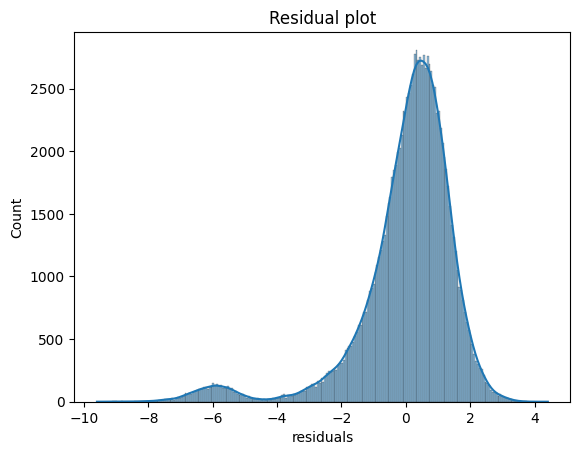

In [52]:
sns.histplot(y1res, kde=True)
plt.title("Residual plot")
plt.xlabel("residuals")
plt.show()

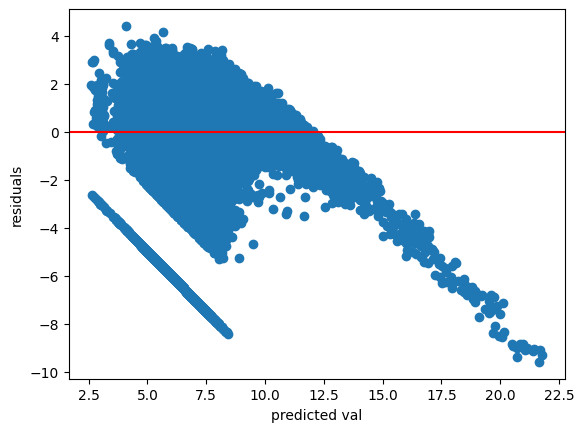

In [53]:
plt.scatter(y1_pred, y1res)
plt.axhline(0,color = "red")
plt.xlabel("predicted val")
plt.ylabel("residuals")
plt.show()

Linear Regression was selected as the baseline model. Despite violations of certain assumptions (multicollinearity, non-normal residuals, heteroscedasticity), the model achieved strong predictive performance (Test R² ≈ 0.95). A log-transformed target experiment improved residual normality but reduced predictive performance substantially (Test R² ≈ 0.40).

In [54]:
sample_df = df.sample(
    10000,
    random_state=42
)

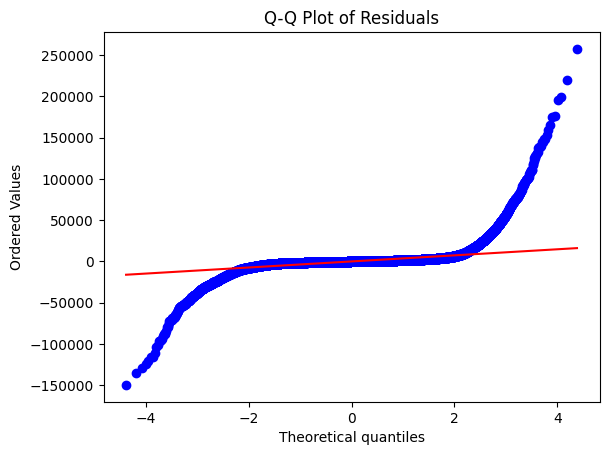

In [55]:
from scipy import stats
import matplotlib.pyplot as plt

stats.probplot(residuals, dist='norm', plot=plt)

plt.title('Q-Q Plot of Residuals')
plt.show()

In [56]:
from sklearn.pipeline import Pipeline

In [57]:
pipe_lr = Pipeline([("preprocessor", transformer),("model", LinearRegression())])

In [58]:
from sklearn.model_selection import KFold, cross_val_score

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [59]:
cv_score = cross_val_score(
    pipe_lr,
    x_train,
    y_train,
    cv=kf,
    scoring="r2",
    n_jobs=1
)

c:\Users\sarth\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\sarth\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\sarth\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\sarth\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [1] during transform. 

In [60]:
print("fold r2 scores: ", cv_score)
print("mean cv r2: ", cv_score.mean())
print("std of fold scores: ", cv_score.std())

fold r2 scores:  [0.78943735 0.76710542 0.78982359 0.79046585 0.79058547]
mean cv r2:  0.7854835380346754
std of fold scores:  0.00919866324751866


Five-fold cross-validation was performed to evaluate the stability of the Linear Regression model. The model achieved a mean cross-validated R² of 0.9523 with a standard deviation of 0.0039, indicating that predictive performance remained highly consistent across different train-validation splits. This suggests that the model generalizes well and that the high test-set performance is not due to a favorable random split.

In [61]:
df_sample = df.sample(n=10000, random_state=42)
num_var = df_sample.select_dtypes(include=['number']).columns.drop('arr_delay')

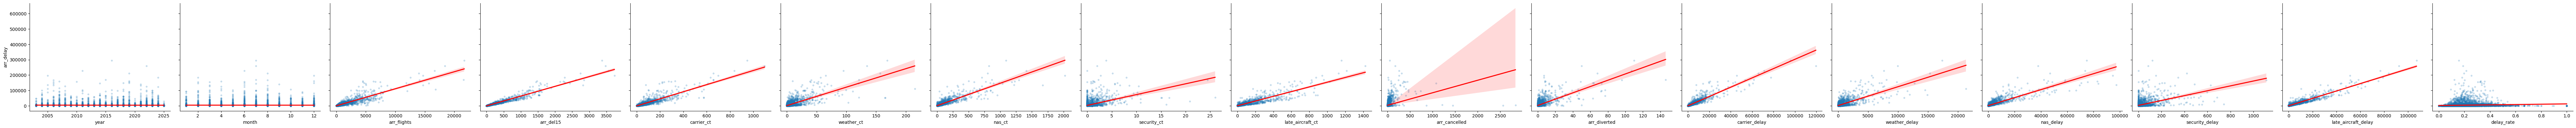

In [62]:
sns.pairplot(
    data=df_sample,
    x_vars=num_var,
    y_vars=['arr_delay'],
    kind='reg',
    plot_kws={
        "scatter_kws": {"alpha":0.2, "s":10},
        "line_kws":{"color":"red"}
    },
    height=4,
    aspect=1.2
)